<a href="https://colab.research.google.com/github/AniyahFJ/IT480-FA26/blob/main/assignment2_transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Aniyah Johnson

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: aniyahfj
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:05<00:00, 77.2MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [6]:
# Your exploration here
import os
import pandas as pd
import matplotlib.pyplot as plt

data_dir_fire = "fire-dataset/fire_dataset"

# Count files in each directory
class_counts = {}
for class_name in os.listdir(data_dir_fire):
    class_path = os.path.join(data_dir_fire, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame
df = pd.DataFrame(list(class_counts.items()), columns=['class', 'count'])
display(df)


,class,count
0,fire_images,755
1,non_fire_images,244


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The biggest thing that I notice about this dataset is that the count of each class is imbalanced. The fire images have a much bigger count than the non fire images. Due to this class weights should be applied.



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [10]:
# Preprocess the data here
def preprocess(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_raw_fire = train_raw_fire.map(preprocess)
val_raw_fire = val_raw_fire.map(preprocess)

# Preprocess test data (accepts both image and label)
def preprocess_test(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

test_raw_fire = test_raw_fire.map(preprocess_test)

In [15]:
# Build your model here
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs, outputs)
model_fire.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# Compile your model here
model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [18]:
# Looked up how to calculate class weights to handle dataset imbalance
total = 755 + 244
weight_for_0 = (1 / 755) * (total / 2.0)
weight_for_1 = (1 / 244) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

# Train your model here
history_fire = model_fire.fit(
    train_raw_fire,
    epochs=10,
    validation_data=val_raw_fire,
    class_weight=class_weight
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6000 - loss: 0.6869 - val_accuracy: 0.7194 - val_loss: 0.6486
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5571 - loss: 0.6856 - val_accuracy: 0.2878 - val_loss: 0.7134
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5971 - loss: 0.6851 - val_accuracy: 0.7266 - val_loss: 0.6436
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4886 - loss: 0.6849 - val_accuracy: 0.7338 - val_loss: 0.6849
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5743 - loss: 0.6838 - val_accuracy: 0.2374 - val_loss: 0.7062
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5914 - loss: 0.6886 - val_accuracy: 0.2446 - val_loss: 0.7043
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5029 - loss: 0.6923 - val_accuracy: 0.2446 - val_loss: 0.7006
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5914 - loss: 0.6848 - val_accuracy: 0.2878 - val_loss:

In [19]:
# Report validation and test accuracy here
val_loss, val_acc = model_fire.evaluate(val_raw_fire)
test_loss, test_acc = model_fire.evaluate(test_raw_fire)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 564ms/step - accuracy: 0.2806 - loss: 0.6958
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 984ms/step - accuracy: 0.5063 - loss: 0.6923
Validation Accuracy: 0.2806
Test Accuracy: 0.5063


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

Part 1 -- Test Accuracy: 0.487


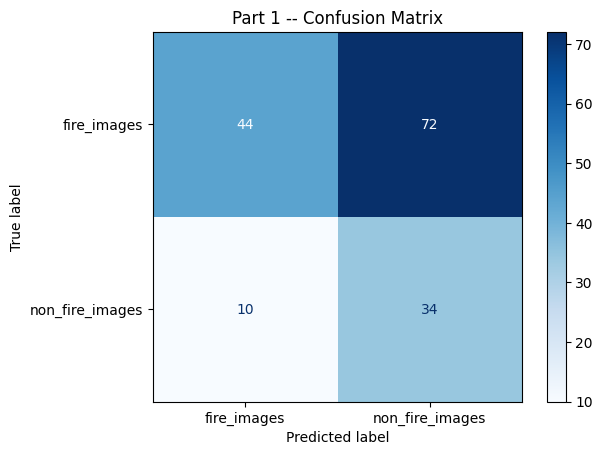

In [22]:
# Build your confusion matrix here

y_true = []
y_probs = []

for images, labels in test_raw_fire:
    preds = model_fire.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# Print Test Accuracy
acc_fire = accuracy_score(y_true, y_pred)
print(f"Part 1 -- Test Accuracy: {acc_fire:.3f}")

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_fire).plot(cmap=plt.cm.Blues)
plt.title("Part 1 -- Confusion Matrix")
plt.show()

*Your answer:* In this situation a false negative is much more costly due to a real fire not getting the response that it needs and potentially endagering others. Since the false positives need to be lowered, I would also lower the decision threshold to make the model more sensitive to fire images.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [23]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [24]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [25]:
# Preprocess the data here
def preprocess(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_raw_sat = train_raw_sat.map(preprocess)
val_raw_sat = val_raw_sat.map(preprocess)

def preprocess_test(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

test_raw_sat = test_raw_sat.map(preprocess_test)

In [26]:
# Build your model here
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_sat.trainable = False

inputs_sat = tf.keras.Input(shape=(224, 224, 3))
x_sat = base_model_sat(inputs_sat, training=False)
x_sat = GlobalAveragePooling2D()(x_sat)
outputs_sat = Dense(10, activation='softmax')(x_sat)

model_sat = Model(inputs_sat, outputs_sat)
model_sat.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
# Compile your model here
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2C — Train and Evaluate

In [28]:
# Train your model here
history_sat = model_sat.fit(
    train_raw_sat,
    epochs=10,
    validation_data=val_raw_sat
)


Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.8783 - loss: 0.3755 - val_accuracy: 0.9306 - val_loss: 0.2172
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 561s 937ms/step - accuracy: 0.9338 - loss: 0.1949 - val_accuracy: 0.9378 - val_loss: 0.1866
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.9478 - loss: 0.1592 - val_accuracy: 0.9395 - val_loss: 0.1804
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 551s 933ms/step - accuracy: 0.9538 - loss: 0.1385 - val_accuracy: 0.9400 - val_loss: 0.1769
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 542s 918ms/step - accuracy: 0.9603 - loss: 0.1220 - val_accuracy: 0.9413 - val_loss: 0.1757
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 571s 933ms/step - accuracy: 0.9639 - loss: 0.1105 - val_accuracy: 0.9400 - val_loss: 0.1838
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 573s 952ms/step - accuracy: 0.9688 - loss: 0.0991 - val_accuracy: 0.9376 - val_loss: 0.1820
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.9714 - loss: 0.

In [29]:
# Report validation and test accuracy here
val_loss, val_acc = model_sat.evaluate(val_raw_sat)
test_loss, test_acc = model_sat.evaluate(test_raw_sat)


127/127 ━━━━━━━━━━━━━━━━━━━━ 108s 836ms/step - accuracy: 0.9443 - loss: 0.1693
127/127 ━━━━━━━━━━━━━━━━━━━━ 113s 891ms/step - accuracy: 0.9412 - loss: 0.1747


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

Part 2 -- Test Accuracy: 0.941


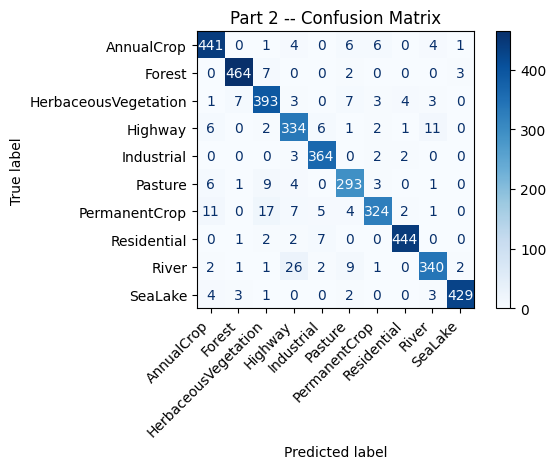

In [32]:
# Build your confusion matrix here
from sklearn.metrics import accuracy_score

y_true = []
y_pred = []

for images, labels in test_raw_sat:
  preds = model_sat.predict(images, verbose=0)
  y_true.extend(labels.numpy())
  # Get the index of the class with the highest probability
  y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print Test Accuracy
acc_sat = accuracy_score(y_true, y_pred)
print(f"Part 2 -- Test Accuracy: {acc_sat:.3f}")

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_sat).plot(cmap=plt.cm.Blues)
plt.title("Part 2 -- Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Your answer:*
The land use classes that get confused most often are Herbaceous Vegetation and Forest. This makes sense because The green vegetation and green forest trees have similar colors and textures that can easily be confused.



---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.2806| 0.9443 |
| Test Accuracy |0.5063 |0.9412|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*


1.   The EuroSAT dataset with the closer match to the original triaing because it acheived a higher test rating of 94% test accuracy. The Fire dataset had the bigger mismatch due to its 50% test accuracy.
2.   The Fire dataset would benefit more from fine-tuning because of the mismatch of the domain. Unfreezing the weights and adjusting them will allow the filters to adapt. There could also be more improvement for the EuroSAT dataset, but it already performed well with a 94% accuracy.





---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
The composition of the Fire dataset affected the training setup and evaluation due to the imbalanced dataset. There were 755 fire images and 244 non-fire images. To minimize the chances of the model only predicting the majoritty class, I calculated the class weights during training. Also during the evaluation I used the confusion matrix instead of just the accuracy alone. For the Fire dataset, I used an output layer size on 1, sigmoid activation function, and binary crossentropy loss function. This combination was used due to this being binary classification. For the EuroSAT dataset I used and output layer size of 10, softmax activation function, and categorical crossentropy, This combination was used due to this being a multi-class classification. Based on my results a pretrained model's usefulness depends on how well its original training matches your task. This is because the EuroSAT acheived a high accuracy of 94% test accuracy and was more closely related to the pretrained model. While the Fire dataset had more of a mismatch and only had a 50% test accuracy.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.